In [129]:
from google.colab import files
uploaded = files.upload()

Saving archive (7).zip to archive (7) (1).zip


In [5]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 2.9 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.regularizers import l1_l2
from keras.optimizers import Adam, RMSprop, SGD
from keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE
import optuna
from sklearn.metrics import accuracy_score

In [130]:
df=pd.read_csv("archive (7).zip")
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [131]:
print(df["Attrition"].unique())

['Yes' 'No']


In [132]:
df["Attrition"] = df["Attrition"].astype(str).str.strip().str.lower()
df["Attrition"] = df["Attrition"].map({"yes": 1, "no": 0})

In [133]:
print(df["Attrition"].value_counts(dropna=False))

Attrition
0    1233
1     237
Name: count, dtype: int64


In [135]:
df.duplicated().sum()

np.int64(0)

In [136]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [138]:
df.head(1)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5


In [139]:
# Convert categorical numeric columns to object type
df["Education"] = df["Education"].astype("object")
df["EnvironmentSatisfaction"] = df["EnvironmentSatisfaction"].astype("object")
df["JobInvolvement"] = df["JobInvolvement"].astype("object")
df["JobLevel"] = df["JobLevel"].astype("object")
df["JobSatisfaction"] = df["JobSatisfaction"].astype("object")
df["PerformanceRating"] = df["PerformanceRating"].astype("object")
df["RelationshipSatisfaction"] = df["RelationshipSatisfaction"].astype("object")
df["StockOptionLevel"] = df["StockOptionLevel"].astype("object")
df["WorkLifeBalance"] = df["WorkLifeBalance"].astype("object")

In [140]:
df["Experience_Outside"] = df["TotalWorkingYears"] - df["YearsAtCompany"]

In [141]:
df["Promotion_Gap"] = df["YearsAtCompany"] - df["YearsSinceLastPromotion"]

In [142]:
df["OverTime_Flag"] = (df["OverTime"] == "Yes").astype(int)

In [143]:
df["Income_Per_Year"] = df["MonthlyIncome"] / (df["TotalWorkingYears"] + 1)

In [144]:
df["Job_Change_Rate"] = df["NumCompaniesWorked"] / (df["TotalWorkingYears"] + 1)

In [145]:
# Frequency encoding for categorical columns

jobrole_freq = df["JobRole"].value_counts(normalize=True)
df["JobRole_freq"] = df["JobRole"].map(jobrole_freq)

dept_freq = df["Department"].value_counts(normalize=True)
df["Department_freq"] = df["Department"].map(dept_freq)

education_freq = df["EducationField"].value_counts(normalize=True)
df["EducationField_freq"] = df["EducationField"].map(education_freq)

marital_freq = df["MaritalStatus"].value_counts(normalize=True)
df["MaritalStatus_freq"] = df["MaritalStatus"].map(marital_freq)

In [146]:
df.drop(columns=["EmployeeNumber", "EmployeeCount", "StandardHours"], inplace=True)

In [147]:
X = df.drop(columns=["Attrition"])
y = df["Attrition"]

In [148]:
X = X.select_dtypes(exclude=["object"])

In [149]:
X_train_full , X_test,y_train_full,y_test = train_test_split(X,y,test_size=0.2,random_state=21,stratify=y)

In [150]:
X_train,X_val,y_train,y_val = train_test_split(X_train_full,y_train_full,test_size=0.2,random_state=21,stratify=y_train_full)

In [151]:
num_cols = X_train.select_dtypes(include=["int64","float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

In [152]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

preprocessor = ColumnTransformer([
    ("num", MinMaxScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [153]:
X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

In [154]:
model = Sequential([
    Input(shape=(X_train_t.shape[1],)),
    Dense(32, activation="relu"),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

In [155]:
model.compile(optimizer="Adam",loss = "binary_crossentropy",metrics = ["accuracy"])


In [156]:
early = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [157]:
model.fit(
    X_train_t,
    y_train,
    validation_data=(X_val_t, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[early],
    verbose=2
)

Epoch 1/50
4/4 - 1s - 311ms/step - accuracy: 0.5830 - loss: 0.6833 - val_accuracy: 0.8178 - val_loss: 0.6317
Epoch 2/50
4/4 - 0s - 22ms/step - accuracy: 0.8213 - loss: 0.6077 - val_accuracy: 0.8390 - val_loss: 0.5688
Epoch 3/50
4/4 - 0s - 22ms/step - accuracy: 0.8383 - loss: 0.5499 - val_accuracy: 0.8390 - val_loss: 0.5214
Epoch 4/50
4/4 - 0s - 22ms/step - accuracy: 0.8383 - loss: 0.5079 - val_accuracy: 0.8390 - val_loss: 0.4863
Epoch 5/50
4/4 - 0s - 23ms/step - accuracy: 0.8383 - loss: 0.4766 - val_accuracy: 0.8390 - val_loss: 0.4618
Epoch 6/50
4/4 - 0s - 25ms/step - accuracy: 0.8383 - loss: 0.4551 - val_accuracy: 0.8390 - val_loss: 0.4464
Epoch 7/50
4/4 - 0s - 22ms/step - accuracy: 0.8383 - loss: 0.4429 - val_accuracy: 0.8390 - val_loss: 0.4377
Epoch 8/50
4/4 - 0s - 23ms/step - accuracy: 0.8383 - loss: 0.4364 - val_accuracy: 0.8390 - val_loss: 0.4336
Epoch 9/50
4/4 - 0s - 23ms/step - accuracy: 0.8383 - loss: 0.4330 - val_accuracy: 0.8390 - val_loss: 0.4312
Epoch 10/50
4/4 - 0s - 23ms

In [162]:
y_pred = np.where(model.predict(X_test_t)>0.5,1,0)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [163]:
accuracy_score(y_pred,y_test)

0.8571428571428571

In [164]:
smote = SMOTE()
X_train_res,y_train_res = smote.fit_resample(X_train_t,y_train)

In [165]:
def objective(trial):
    lr_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    n_layers = trial.suggest_int('n_layers', 1, 4)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD'])
    activation = trial.suggest_categorical('activation', ['tanh', 'relu'])
    batch_size1 = trial.suggest_categorical('batch_size', [32, 64, 128, 256, 512])

    model = Sequential()
    model.add(Input(shape=(X_train_res.shape[1],)))
    for i in range(n_layers):
        units = trial.suggest_int(f'units{i}', 8, 96)
        dropout = trial.suggest_float(f'dropout{i}', 0.0, 0.5)
        reg = trial.suggest_float(f'reg{i}', 1e-5, 1e-2, log=True)
        model.add(Dense(units, activation=activation, kernel_regularizer=l1_l2(l1=reg, l2=reg)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))

    opt_map = {
        'Adam': Adam(learning_rate=lr_rate),
        'RMSprop': RMSprop(learning_rate=lr_rate),
        'SGD': SGD(learning_rate=lr_rate)
    }
    model.compile(optimizer=opt_map[optimizer_name], loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.Recall(name='recall')])

    es = EarlyStopping(monitor='val_recall', mode='max', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train_res, y_train_res,
        epochs=30, batch_size=batch_size1,
        validation_data=(X_val_t, y_val),   # validation set, NOT test
        callbacks=[es], verbose=0
    )
    return max(history.history['val_recall'])

In [166]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=21))
study.optimize(objective, n_trials=5, show_progress_bar=True)

[I 2026-06-28 11:52:51,697] A new study created in memory with name: no-name-2ffafab6-d9b4-458e-94c8-45802545686a


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-06-28 11:52:58,913] Trial 0 finished with value: 0.7368420958518982 and parameters: {'learning_rate': 0.0001251554487151282, 'n_layers': 2, 'optimizer': 'Adam', 'activation': 'relu', 'batch_size': 512, 'units0': 19, 'dropout0': 0.08906233077974918, 'reg0': 0.00030746001885481724, 'units1': 84, 'dropout1': 0.37947191775605715, 'reg1': 0.008155589837765905}. Best is trial 0 with value: 0.7368420958518982.
[I 2026-06-28 11:53:02,028] Trial 1 finished with value: 0.8421052694320679 and parameters: {'learning_rate': 0.00330069279804087, 'n_layers': 2, 'optimizer': 'RMSprop', 'activation': 'relu', 'batch_size': 32, 'units0': 37, 'dropout0': 0.23007016689648802, 'reg0': 0.0004296403664910425, 'units1': 27, 'dropout1': 0.39993416346948824, 'reg1': 0.001513747182776292}. Best is trial 1 with value: 0.8421052694320679.
[I 2026-06-28 11:53:05,531] Trial 2 finished with value: 1.0 and parameters: {'learning_rate': 0.004995574347086988, 'n_layers': 2, 'optimizer': 'RMSprop', 'activation': '

In [185]:
study.best_params

{'learning_rate': 0.004995574347086988,
 'n_layers': 2,
 'optimizer': 'RMSprop',
 'activation': 'relu',
 'batch_size': 64,
 'units0': 78,
 'dropout0': 0.4438277186036015,
 'reg0': 0.00124905731421375,
 'units1': 48,
 'dropout1': 0.15295758239442775,
 'reg1': 0.0028857135238802138}

In [186]:
model  = Sequential()

# Input Layer
model.add(Input(shape=(X_train_res.shape[1],)))

In [187]:
# 1st hidden Layer

model.add(Dense(37,activation='relu',kernel_initializer='he_normal',kernel_regularizer=l1_l2(l1=0.00124905731421375,l2 = 0.00124905731421375)))
model.add(BatchNormalization())
model.add(Dropout(0.4438277186036015,))

# 2nd layer

model.add(Dense(27,activation='relu',kernel_initializer='he_normal',kernel_regularizer=l1_l2(l1=0.0028857135238802138,l2 =0.0028857135238802138 )))
model.add(BatchNormalization())
model.add(Dropout(0.15295758239442775))
# Output layer

model.add(Dense(1,activation='sigmoid',kernel_initializer="glorot_uniform"))


In [188]:
model.compile(optimizer=RMSprop(learning_rate=0.004995574347086988), loss='binary_crossentropy',
                  metrics=["accuracy",tf.keras.metrics.Recall(name='recall')])

In [189]:
es = EarlyStopping(monitor='val_recall', mode='max', patience=5, restore_best_weights=True)

In [190]:
history = model.fit(
        X_train_res, y_train_res,
        epochs=30, batch_size=32,
        validation_data=(X_val_t, y_val),   # validation set, NOT test
        callbacks=[es], verbose=0
    )

In [191]:
y_pred=np.where(model.predict(X_test_t)>0.5,1,0)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [192]:
accuracy_score(y_pred,y_test)

0.5918367346938775

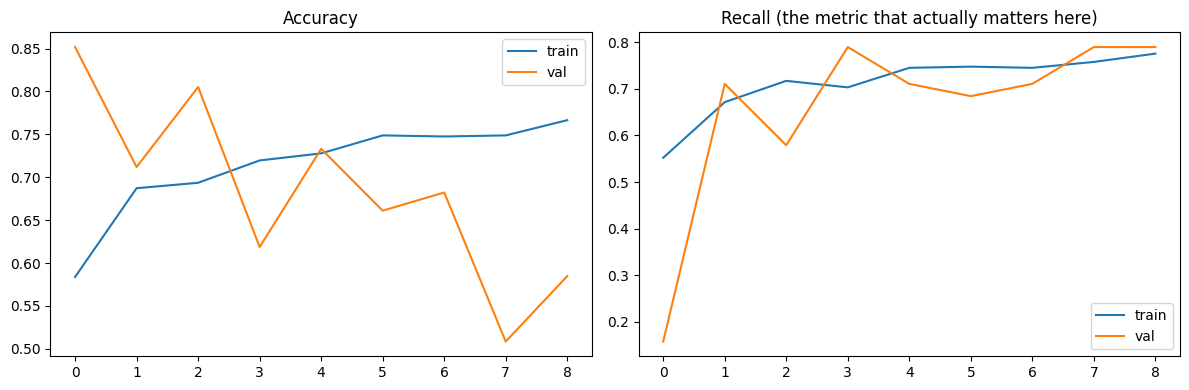

In [193]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy'); axes[0].legend()

axes[1].plot(history.history['recall'], label='train')
axes[1].plot(history.history['val_recall'], label='val')
axes[1].set_title('Recall (the metric that actually matters here)'); axes[1].legend()
plt.tight_layout()
plt.show()

In [194]:
# Training accuracy
y_pred_train = np.where(model.predict(X_train_res) > 0.5, 1, 0)
train_acc = accuracy_score(y_train_res, y_pred_train)

# Validation accuracy
y_pred_val = np.where(model.predict(X_val_t) > 0.5, 1, 0)
val_acc = accuracy_score(y_val, y_pred_val)

# Test accuracy
y_pred_test = np.where(model.predict(X_test_t) > 0.5, 1, 0)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Train Accuracy      : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Train Accuracy      : 0.7329
Validation Accuracy : 0.6186
Test Accuracy       : 0.5918


In [195]:
# Mild OVerfit but good model

In [196]:
# Because your test set is imbalanced (original distribution, no SMOTE),
# a model predicting mostly class 0 can easily hit 82% accuracy while catching almost no laundering cases.

In [197]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.93      0.55      0.70       247
           1       0.25      0.79      0.38        47

    accuracy                           0.59       294
   macro avg       0.59      0.67      0.54       294
weighted avg       0.82      0.59      0.65       294



In [198]:
import pickle

with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

model.save('model.keras')
print("Saved preprocessor.pkl and model.keras")

Saved preprocessor.pkl and model.keras
